In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import kagglehub as kh
import os
import keras
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from helper import *
from keras.layers import LSTM, Dense, RepeatVector, TimeDistributed, Input, BatchNormalization
from scipy.stats import spearmanr

%matplotlib inline

In [2]:
training = True

In [3]:
tf.random.set_seed(42)

In [4]:
path = kh.dataset_download("palbha/cmapss-jet-engine-simulated-data")

In [5]:
col_names = ['Unit', 'Cycle Time', 'Op1', 'Op2', 'Op3'] + [f'Sensor {_+1}' for _ in range(23)]
df = pd.read_csv(os.path.join(path, 'train_FD001.txt'), sep=' ', header=None, names=col_names)
df_test = pd.read_csv(os.path.join(path, 'test_FD001.txt'), sep=' ', header=None, names=col_names)

In [6]:
df.head()

,Unit,Cycle Time,Op1,Op2,Op3,Sensor 1,Sensor 2,Sensor 3,Sensor 4,Sensor 5,...,Sensor 14,Sensor 15,Sensor 16,Sensor 17,Sensor 18,Sensor 19,Sensor 20,Sensor 21,Sensor 22,Sensor 23
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,NaN,NaN
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,NaN,NaN
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,NaN,NaN
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,NaN,NaN
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,NaN,NaN


In [7]:
# Using to_string with specific formatting
with open('data_summary_FD001.txt', 'w') as f:
    f.write("CMAPSS Dataset Summary Statistics\n")
    f.write("="*30 + "\n")
    f.write(df.describe().transpose().to_string()) # Transpose makes it easier to read if you have many sensors

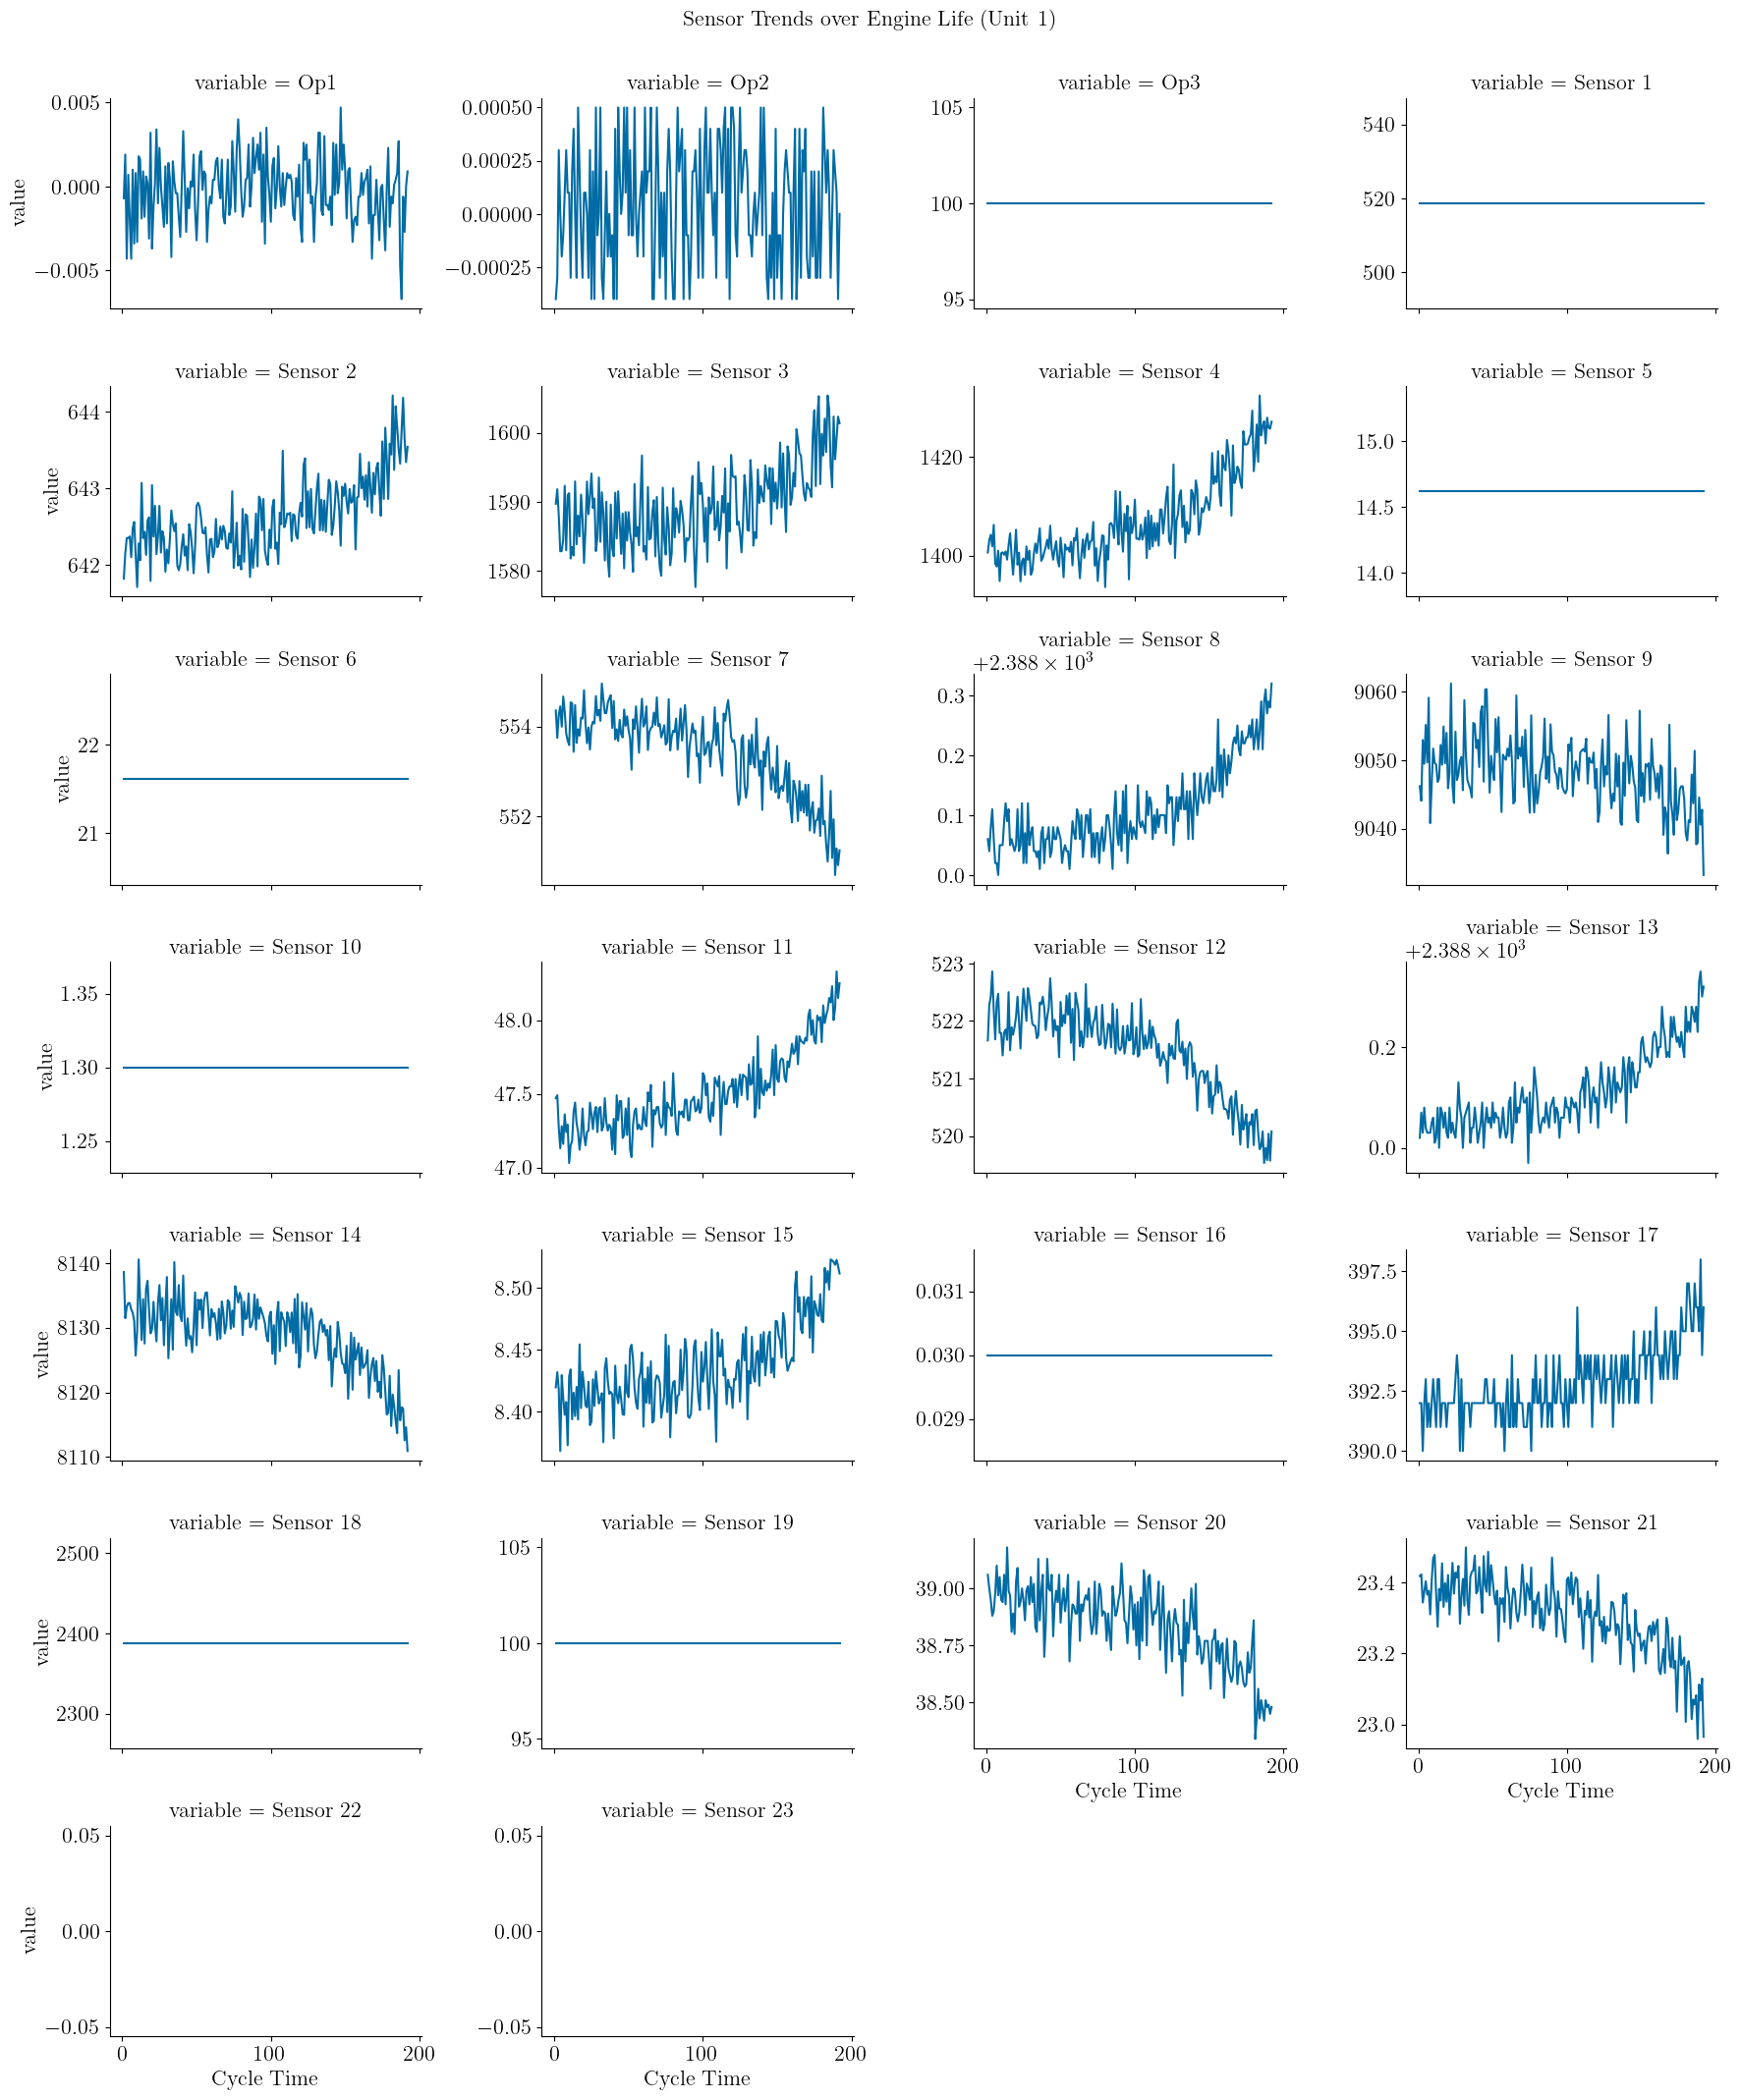

In [8]:
fig = sensor_explore_plot(df, ids='Cycle Time', values=['Op1', 'Op2', 'Op3'] + [f'Sensor {_+1}' for _ in range(23)])
plt.show()

In [9]:
cols_to_drop = ['Sensor 1', 'Sensor 5', 'Sensor 6', 'Sensor 10', 'Sensor 16', 'Sensor 17', 'Sensor 18', 'Sensor 19', 'Sensor 22', 'Sensor 23']
relevant_sensors = [f'Sensor {_+1}' for _ in range(23) if _ not in (0, 4, 5, 9, 15, 16, 17, 18, 21, 22)]
ops = ['Op1', 'Op2']
df = df.drop(columns=cols_to_drop)
df_test = df_test.drop(columns=cols_to_drop)
df.head()

,Unit,Cycle Time,Op1,Op2,Op3,Sensor 2,Sensor 3,Sensor 4,Sensor 7,Sensor 8,Sensor 9,Sensor 11,Sensor 12,Sensor 13,Sensor 14,Sensor 15,Sensor 20,Sensor 21
0,1,1,-0.0007,-0.0004,100.0,641.82,1589.70,1400.60,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,642.15,1591.82,1403.14,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,642.35,1587.99,1404.20,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,642.35,1582.79,1401.87,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,642.37,1582.85,1406.22,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,38.90,23.4044


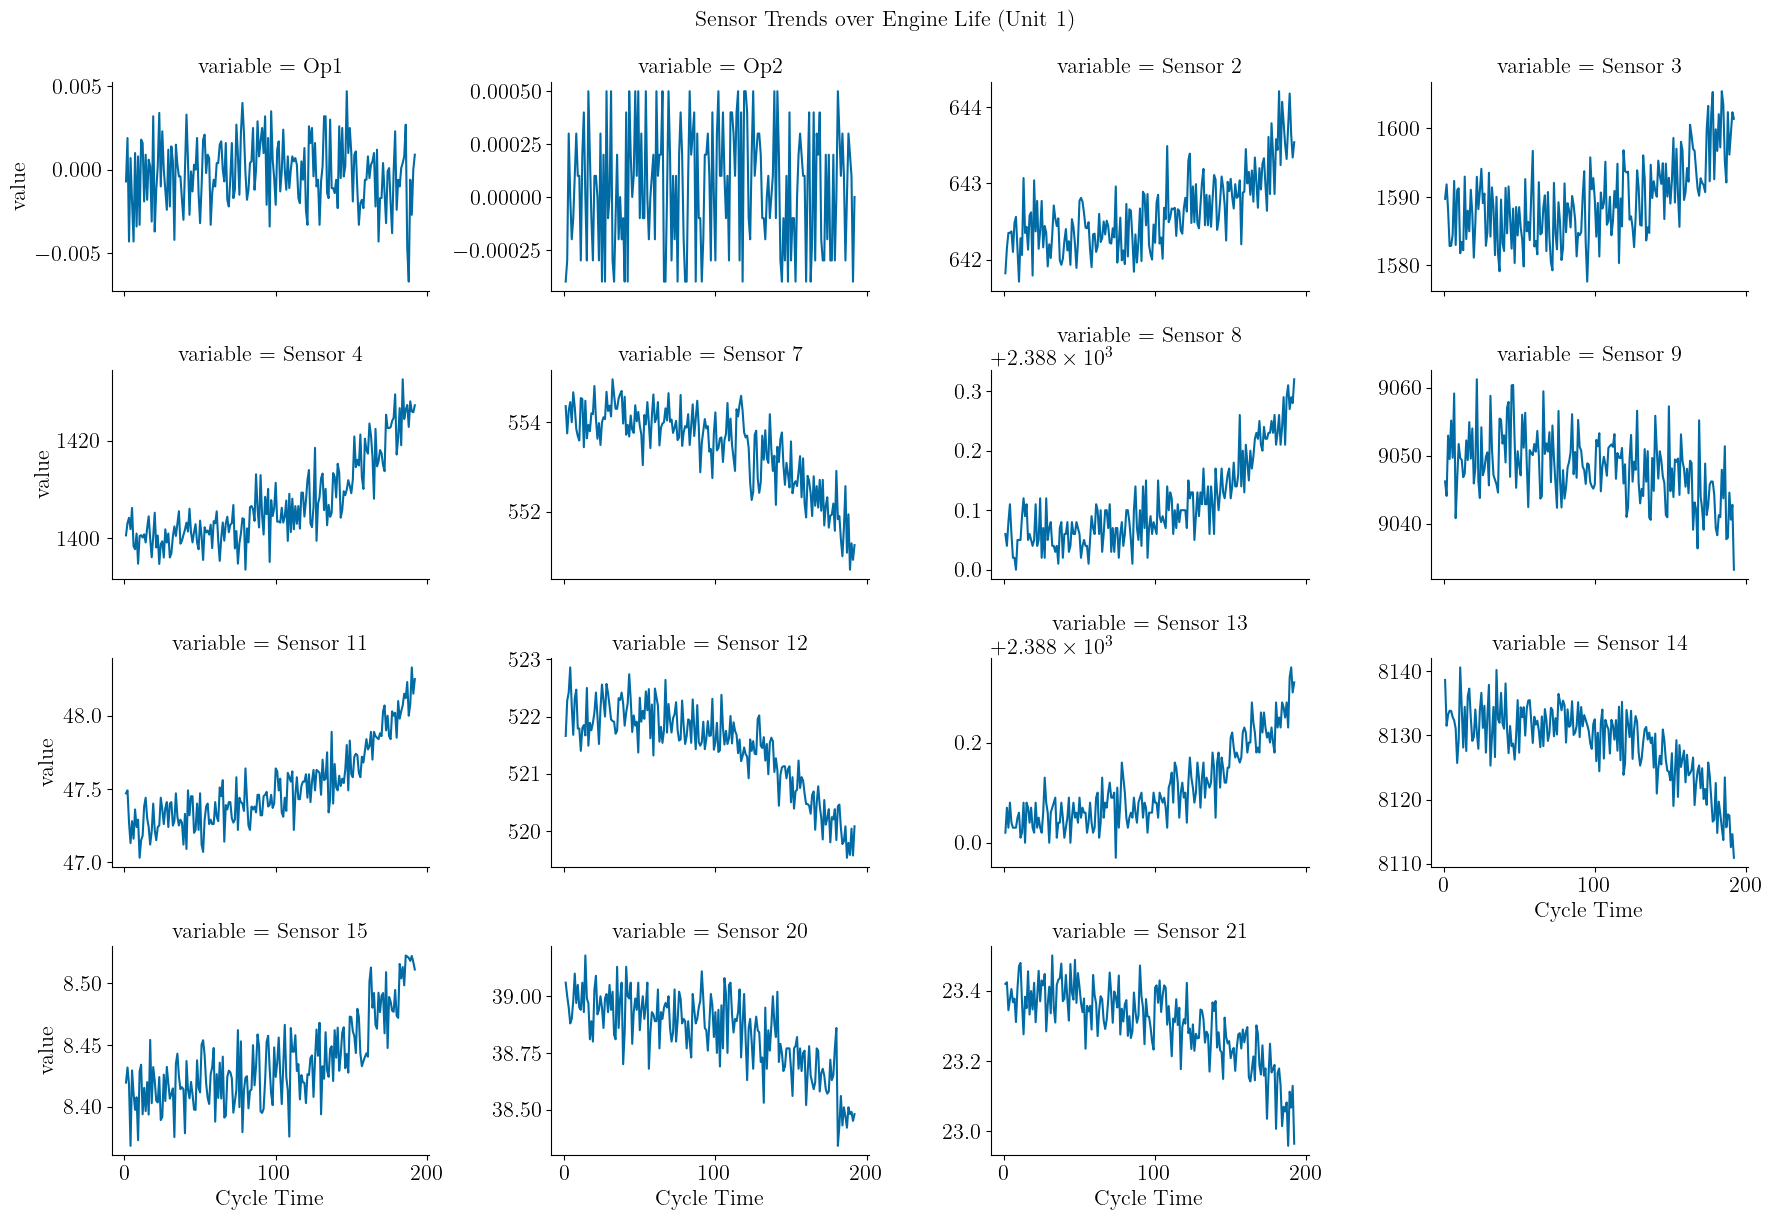

In [10]:
fig = sensor_explore_plot(df, ids='Cycle Time', values=ops+relevant_sensors)
plt.show()

In [11]:
print(relevant_sensors)

['Sensor 2', 'Sensor 3', 'Sensor 4', 'Sensor 7', 'Sensor 8', 'Sensor 9', 'Sensor 11', 'Sensor 12', 'Sensor 13', 'Sensor 14', 'Sensor 15', 'Sensor 20', 'Sensor 21']


In [12]:
wsize = 50

# Fit ONLY on the first 50 cycles of the training data 
# This defines the 0.0 to 1.0 range based on HEALTHY engines
scaler = MinMaxScaler()
scaler.fit(df.groupby('Unit').head(wsize)[ops + relevant_sensors])

# Transform everything using that "Healthy Range"
df[ops + relevant_sensors] = scaler.transform(df[ops + relevant_sensors])
df_test[ops + relevant_sensors] = scaler.transform(df_test[ops + relevant_sensors])

In [13]:
X_train, Y_train = gen_train_windows_multi(df, wsize, ops, relevant_sensors)
X_test, Y_test, test_units = gen_test_windows_multi(df_test, wsize, ops, relevant_sensors)

In [14]:
print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)
print(Y_test.shape)

(100, 50, 15)
(100, 50, 13)
(93, 50, 15)
(93, 50, 13)


In [15]:
# Define dimensions based on your lists
n_inputs = len(ops) + len(relevant_sensors) # Total features in X_train
n_targets = len(relevant_sensors)            # Only the sensors in Y_train

# 1. Input Layer
# Matches the shape (window_size, total_features)
inputs = Input(shape=(wsize, n_inputs))

# 2. Encoder
# Processes both Ops and Sensors to find the 'hidden' health state
encoder = LSTM(64, activation='tanh', return_sequences=False)(inputs)

# 3. Bottleneck
# Bridges the single 'thought vector' back into a sequence
bottleneck = RepeatVector(wsize)(encoder)

# 4. Decoder
decoder = LSTM(64, activation='tanh', return_sequences=True)(bottleneck)

# 5. Output Layer
# This MUST match n_targets so it only reconstructs the health sensors
outputs = TimeDistributed(Dense(n_targets))(decoder)

# Create the Model object
model = keras.models.Model(inputs=inputs, outputs=outputs)

# Compile
model.compile(optimizer='adam', loss='mae')

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 50, 15)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        20,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 50, 13)         │           845 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,349 (212.30 KB)

 Trainable params: 54,349 (212.30 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
callbacks = [keras.callbacks.EarlyStopping(monitor='val_loss', patience=5),
             keras.callbacks.ModelCheckpoint(filepath='best_model_fd001.keras', monitor='val_loss', save_best_only=True)]

if training:
    history = model.fit(
        X_train, Y_train, 
        epochs=50, 
        batch_size=32, 
        validation_split=0.1, 
        verbose=1,
        callbacks=callbacks
    )

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 126ms/step - loss: 0.4730 - val_loss: 0.3239
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.2950 - val_loss: 0.2166
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.2065 - val_loss: 0.1569
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.1555 - val_loss: 0.1518
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.1518 - val_loss: 0.1508
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.1486 - val_loss: 0.1394
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.1362 - val_loss: 0.1255
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.1247 - val_loss: 0.1209
Epoch 9/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.1197 - val_loss: 0.1151
Epoch 10/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.1117 - val_loss: 0.1083
Epoch 11/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.1057 - val_loss: 0.1065
Epoch 12/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.1044 - val_loss: 0.1030


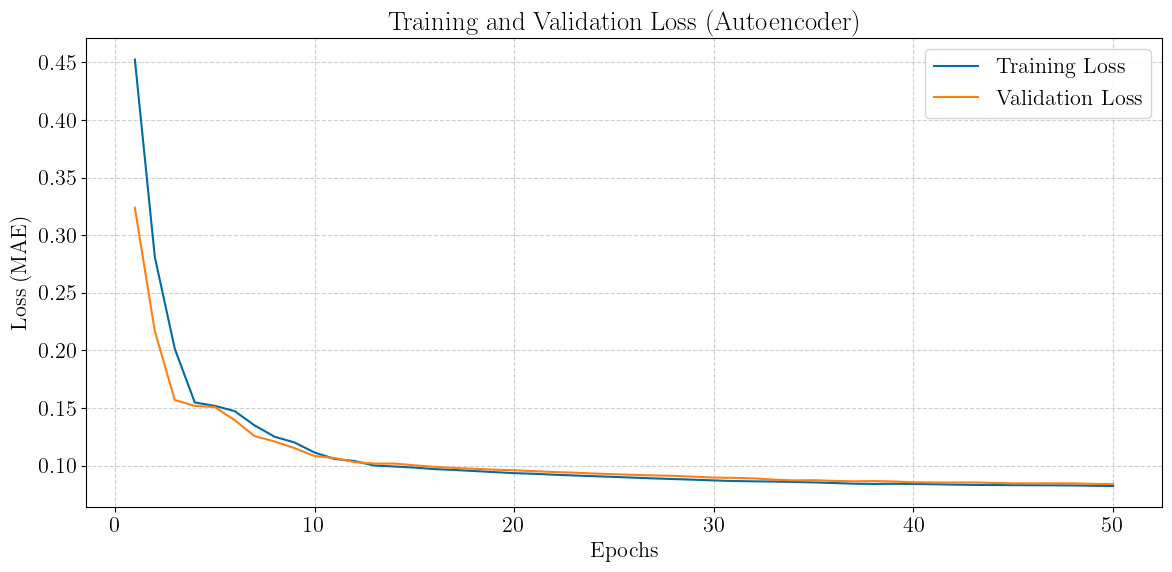

In [17]:
if training:
    fig = make_loss_plot(history)
    plt.show()

In [18]:
model = keras.models.load_model('best_model_fd001.keras')

In [19]:
Y_train_pred = model.predict(X_train)
train_mae_loss = np.mean(np.abs(Y_train_pred - Y_train), axis=(1, 2))

# Set the threshold: Anything 3 standard deviations above the mean error is a "Failure"
threshold = np.percentile(train_mae_loss, 97.5)

print(f"Quiet Failure Threshold: {threshold}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
Quiet Failure Threshold: 0.08625250270147707


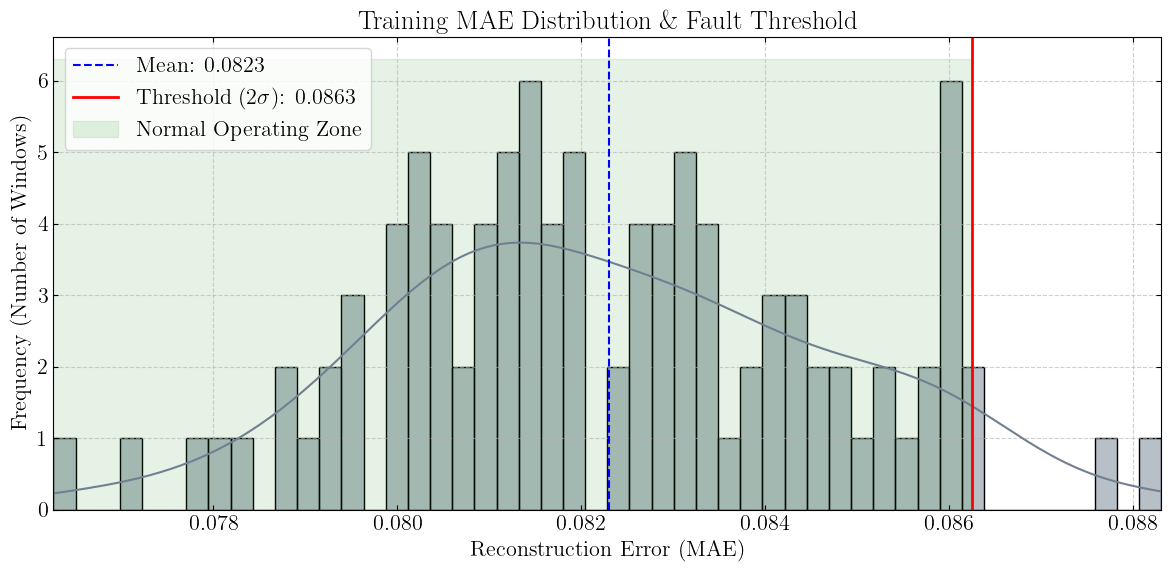

In [20]:
fig = plot_threshold_justification(train_mae_loss, threshold)
plt.show()

In [21]:
Y_test_pred = model.predict(X_test)
test_mae_loss = np.mean(np.abs(Y_test_pred - Y_test), axis=(1, 2))

# Identify which units have crossed the threshold
is_failing = test_mae_loss > threshold

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


In [22]:
print(is_failing)

[False False False False False False False False False False False False
 False  True  True  True  True  True False  True False  True  True False
  True  True  True  True  True  True  True  True  True  True  True  True
 False False False  True False False  True False False  True  True False
 False  True False  True False False  True  True  True  True  True  True
 False  True False False False False False False  True  True  True False
 False False  True  True False  True False  True False False  True  True
  True  True  True False False False False False  True]


In [23]:
rul = pd.read_csv(os.path.join(path, 'rul_FD001.txt'), names=['RUL',])
rul['Unit'] = rul.index+1
rul.head()

,RUL,Unit
0,112,1
1,98,2
2,69,3
3,82,4
4,91,5


In [24]:
anomaly_score = failure_detection(df_test, model, 3, threshold, wsize, ops, relevant_sensors)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Quiet Failure detected at Cycle: 56


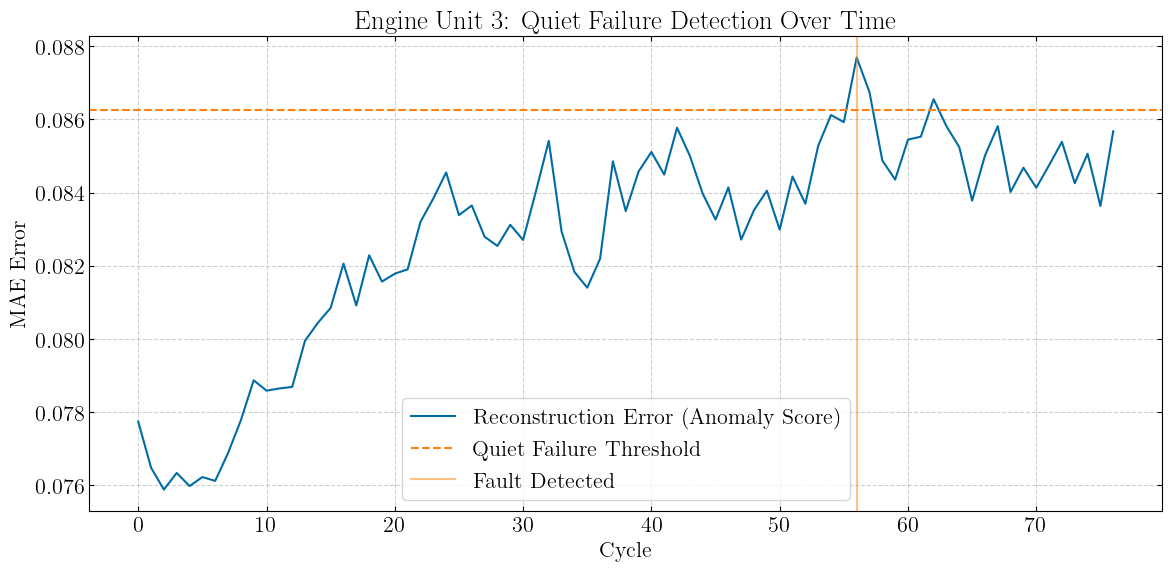

In [25]:
fig = failure_plot(anomaly_score, threshold, unit_no=3)
plt.show()

In [26]:
anomaly_score = failure_detection(df_test, model, 17, threshold, wsize, ops, relevant_sensors)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Quiet Failure detected at Cycle: 58


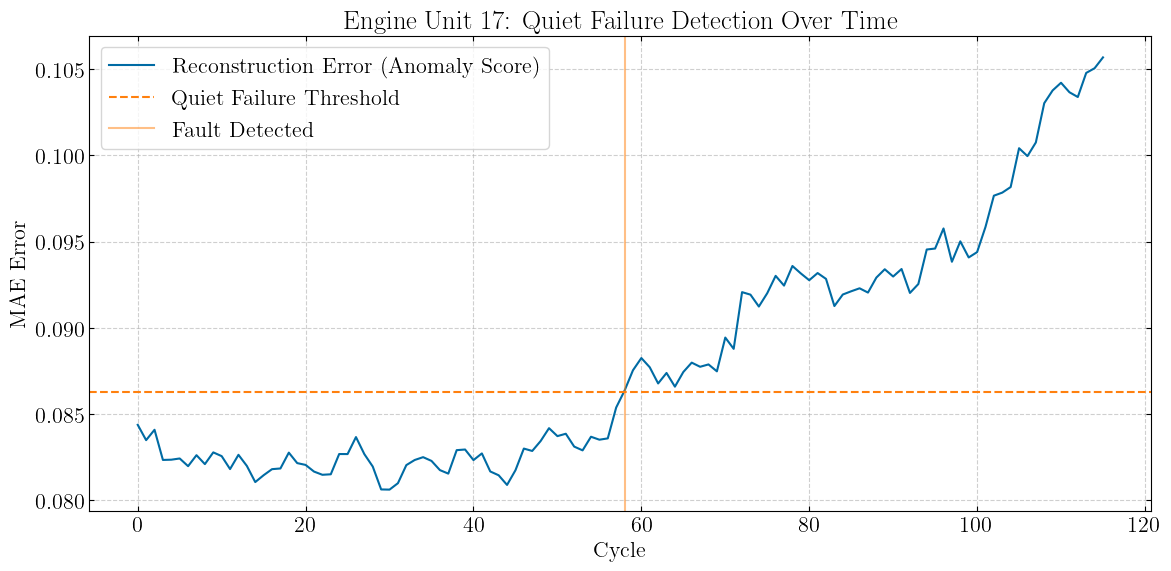

In [27]:
fig = failure_plot(anomaly_score, threshold, unit_no=17)
plt.show()

In [28]:
rul_truth = pd.read_csv(os.path.join(path, 'RUL_FD001.txt'), header=None).values.flatten()

audit_df = generate_audit_results(df_test, rul_truth, model, wsize, ops, relevant_sensors)

print("Top 10 Engines with Highest Anomaly Scores:")
audit_df.head(10)

Top 10 Engines with Highest Anomaly Scores:


,Unit,Max_Anomaly_Score,Actual_RUL
19,24,0.183220,20
92,100,0.172996,20
59,66,0.155365,14
29,35,0.153102,11
69,76,0.152764,10
25,31,0.146271,8
74,81,0.144914,8
28,34,0.144441,7
35,42,0.135156,10
61,68,0.133435,8


0.08301042857238687 0.03489794580628879 0.08377059624821308


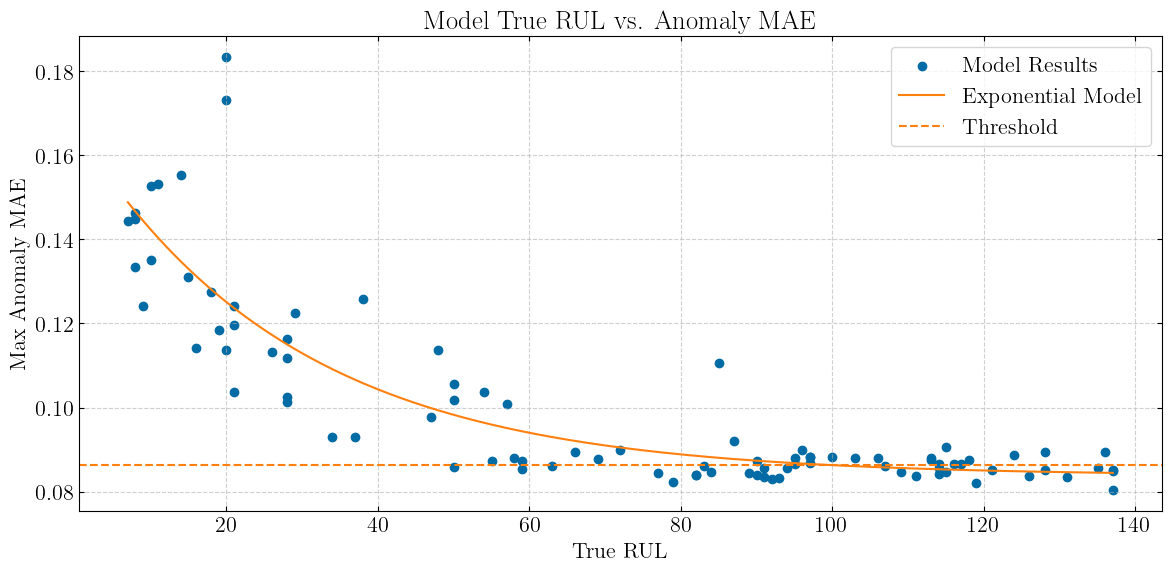

In [29]:
fig = anomaly_rul_plot(audit_df, threshold)
plt.show()

In [30]:
# 1. Using Pandas (Quickest way)
spearman_corr = audit_df['Actual_RUL'].corr(audit_df['Max_Anomaly_Score'], method='spearman')
print(f"Spearman Correlation: {spearman_corr:.4f}")

# 2. Using SciPy (Gives you a p-value for scientific proof)
rho, p_value = spearmanr(audit_df['Actual_RUL'], audit_df['Max_Anomaly_Score'])

print(f"Spearman's rho: {rho:.4f}")
print(f"P-value: {p_value:.4e}")

if p_value < 0.05:
    print("The correlation is statistically significant.")

Spearman Correlation: -0.7509
Spearman's rho: -0.7509
P-value: 4.3948e-18
The correlation is statistically significant.


In [31]:
col_names = ['Unit', 'Cycle Time', 'Op1', 'Op2', 'Op3'] + [f'Sensor {_+1}' for _ in range(23)]
df = pd.read_csv(os.path.join(path, 'train_FD004.txt'), sep=' ', header=None, names=col_names)
df_test = pd.read_csv(os.path.join(path, 'test_FD004.txt'), sep=' ', header=None, names=col_names)

In [32]:
df.head()

,Unit,Cycle Time,Op1,Op2,Op3,Sensor 1,Sensor 2,Sensor 3,Sensor 4,Sensor 5,...,Sensor 14,Sensor 15,Sensor 16,Sensor 17,Sensor 18,Sensor 19,Sensor 20,Sensor 21,Sensor 22,Sensor 23
0,1,1,42.0049,0.8400,100.0,445.00,549.68,1343.43,1112.93,3.91,...,8074.83,9.3335,0.02,330,2212,100.00,10.62,6.3670,NaN,NaN
1,1,2,20.0020,0.7002,100.0,491.19,606.07,1477.61,1237.50,9.35,...,8046.13,9.1913,0.02,361,2324,100.00,24.37,14.6552,NaN,NaN
2,1,3,42.0038,0.8409,100.0,445.00,548.95,1343.12,1117.05,3.91,...,8066.62,9.4007,0.02,329,2212,100.00,10.48,6.4213,NaN,NaN
3,1,4,42.0000,0.8400,100.0,445.00,548.70,1341.24,1118.03,3.91,...,8076.05,9.3369,0.02,328,2212,100.00,10.54,6.4176,NaN,NaN
4,1,5,25.0063,0.6207,60.0,462.54,536.10,1255.23,1033.59,7.05,...,7865.80,10.8366,0.02,305,1915,84.93,14.03,8.6754,NaN,NaN


In [33]:
# Using to_string with specific formatting
with open('data_summary_FD004.txt', 'w') as f:
    f.write("CMAPSS Dataset Summary Statistics\n")
    f.write("="*30 + "\n")
    f.write(df.describe().transpose().to_string()) # Transpose makes it easier to read if you have many sensors

In [34]:
cols_to_drop = ['Sensor 22', 'Sensor 23']
relevant_sensors = [f'Sensor {_+1}' for _ in range(20)]
ops = ['Op1', 'Op2', 'Op3']
df = df.drop(columns=cols_to_drop)
df_test = df_test.drop(columns=cols_to_drop)
df.head()

,Unit,Cycle Time,Op1,Op2,Op3,Sensor 1,Sensor 2,Sensor 3,Sensor 4,Sensor 5,...,Sensor 12,Sensor 13,Sensor 14,Sensor 15,Sensor 16,Sensor 17,Sensor 18,Sensor 19,Sensor 20,Sensor 21
0,1,1,42.0049,0.8400,100.0,445.00,549.68,1343.43,1112.93,3.91,...,129.78,2387.99,8074.83,9.3335,0.02,330,2212,100.00,10.62,6.3670
1,1,2,20.0020,0.7002,100.0,491.19,606.07,1477.61,1237.50,9.35,...,312.59,2387.73,8046.13,9.1913,0.02,361,2324,100.00,24.37,14.6552
2,1,3,42.0038,0.8409,100.0,445.00,548.95,1343.12,1117.05,3.91,...,129.62,2387.97,8066.62,9.4007,0.02,329,2212,100.00,10.48,6.4213
3,1,4,42.0000,0.8400,100.0,445.00,548.70,1341.24,1118.03,3.91,...,129.80,2388.02,8076.05,9.3369,0.02,328,2212,100.00,10.54,6.4176
4,1,5,25.0063,0.6207,60.0,462.54,536.10,1255.23,1033.59,7.05,...,164.11,2028.08,7865.80,10.8366,0.02,305,1915,84.93,14.03,8.6754


In [35]:
df[relevant_sensors] = df[relevant_sensors].astype('float64')
df_test[relevant_sensors] = df_test[relevant_sensors].astype('float64')

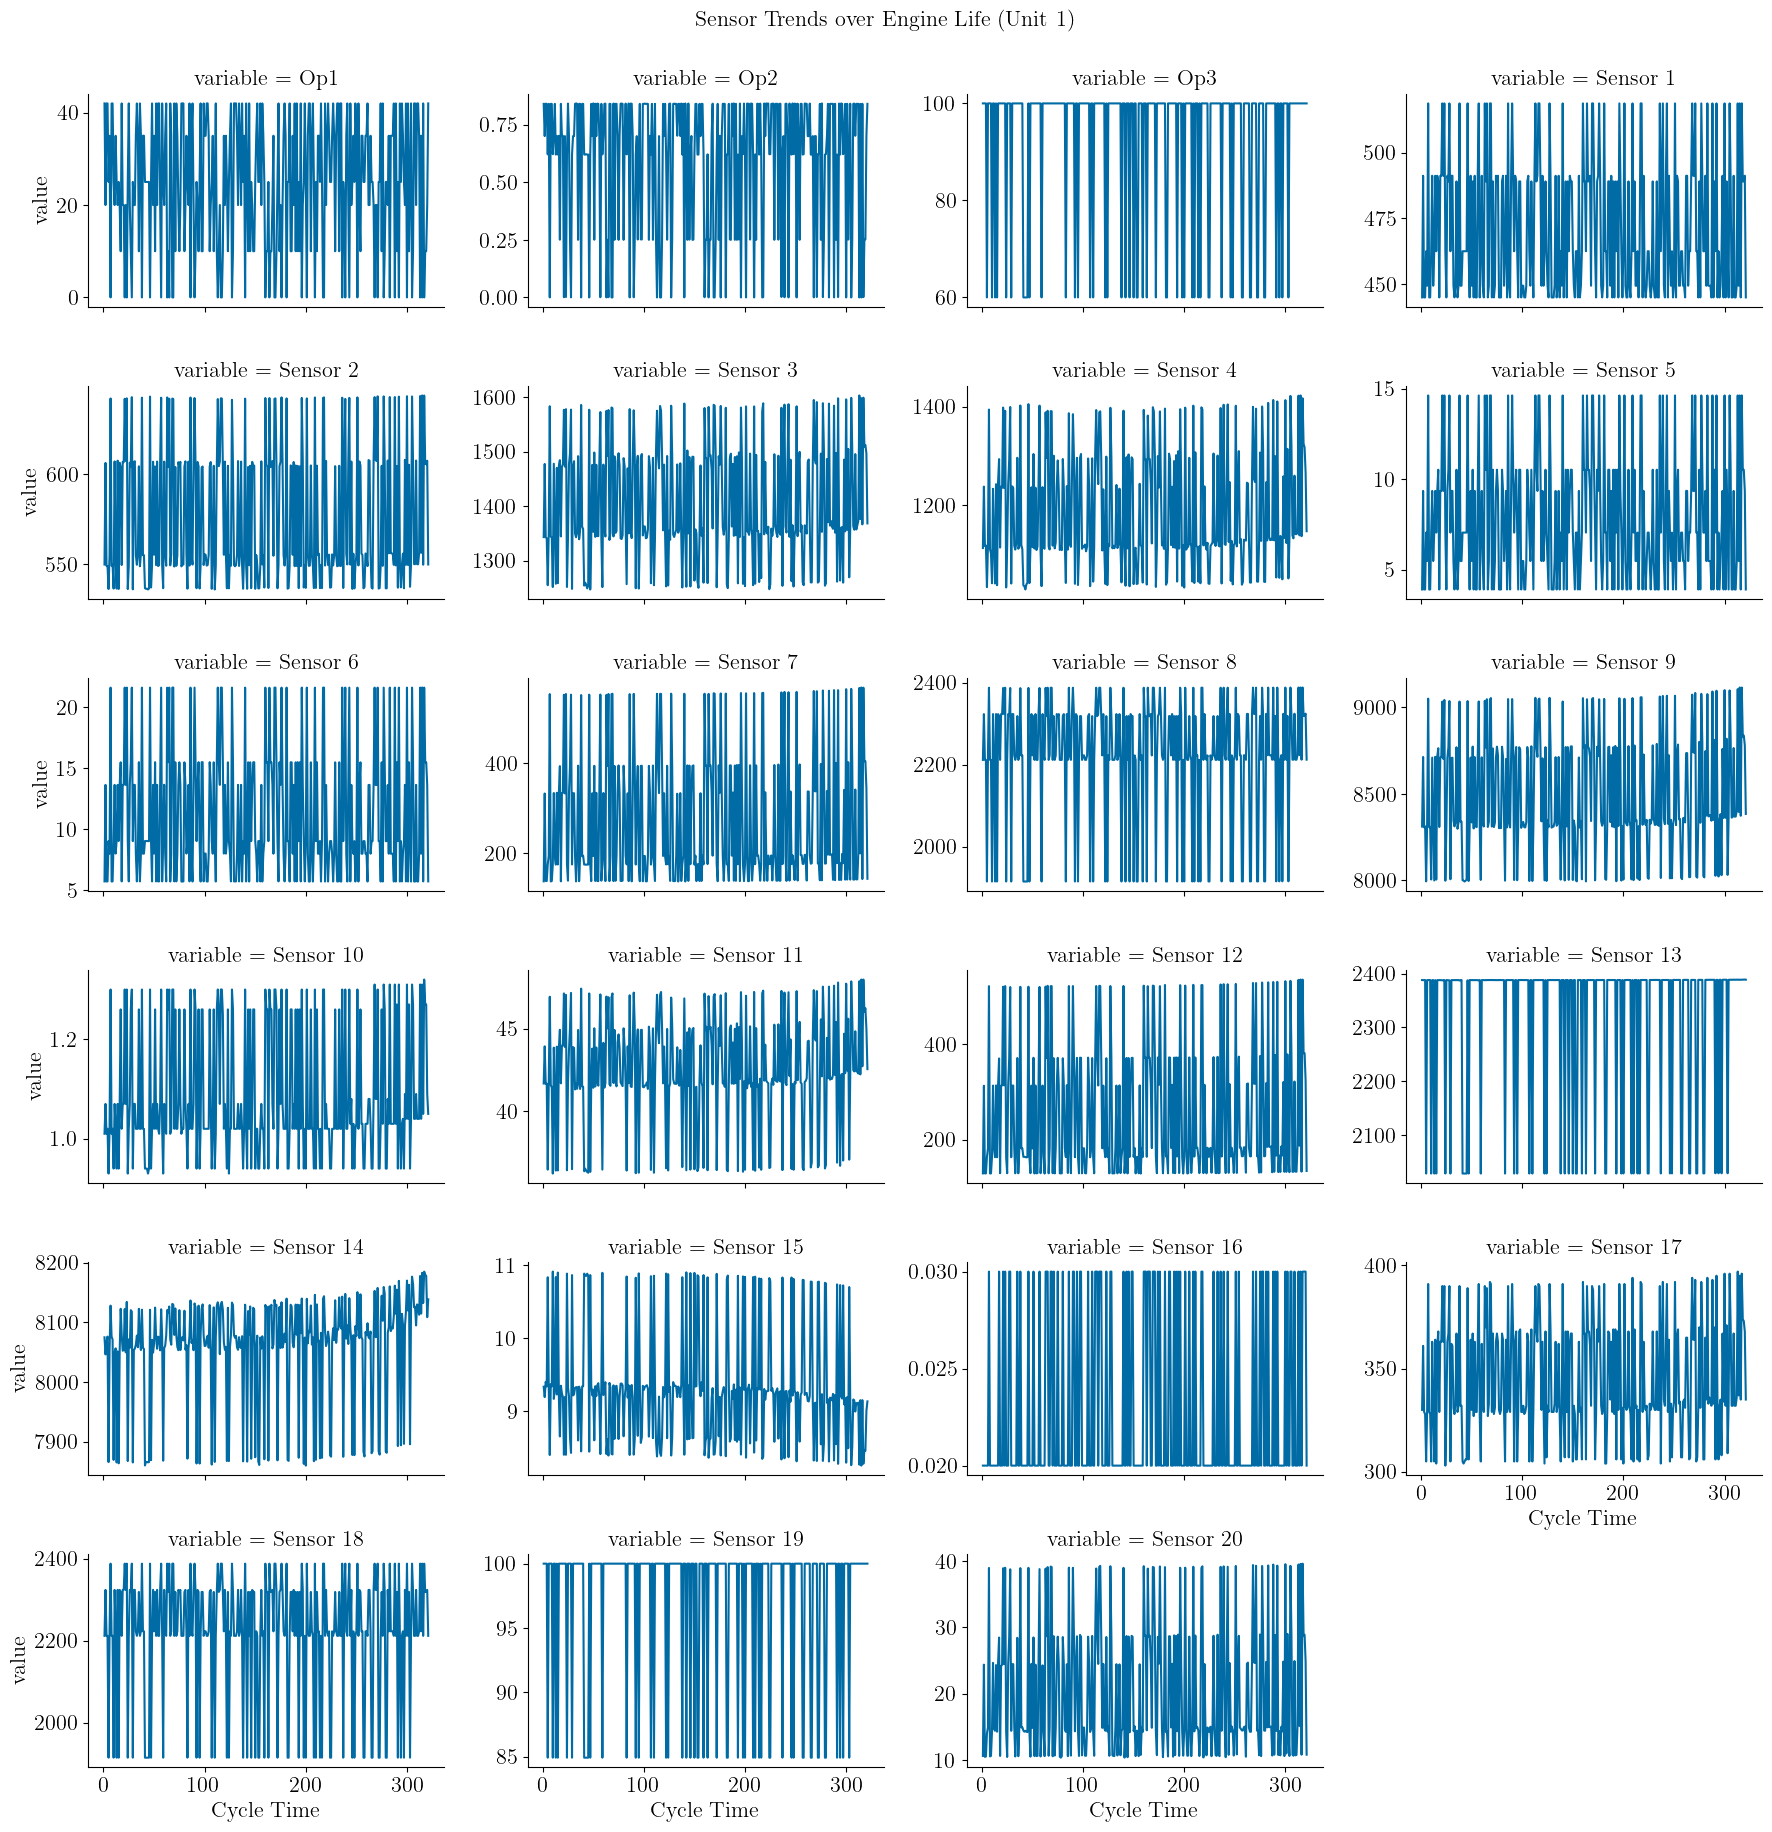

In [36]:
fig = sensor_explore_plot(df, ids='Cycle Time', values=ops+relevant_sensors)
plt.show()

In [37]:
cols_to_drop = ['Sensor 13', 'Sensor 16', 'Sensor 19']
df = df.drop(columns=cols_to_drop)
df_test = df_test.drop(columns=cols_to_drop)

In [38]:
relevant_sensors.remove('Sensor 13')
relevant_sensors.remove('Sensor 16')
relevant_sensors.remove('Sensor 19')

In [39]:
# 1. Add a 'Regime' column to your data (this is a common FD004 trick)
# This rounds the Op settings to identify the 6 discrete clusters
df['Regime'] = df[ops].round(1).astype(str).sum(axis=1)
df_test['Regime'] = df_test[ops].round(1).astype(str).sum(axis=1)

# 2. Scale each sensor per regime
for s in relevant_sensors:
    for regime in df['Regime'].unique():
        mask = (df['Regime'] == regime)
        test_mask = (df_test['Regime'] == regime)
        
        # Fit ONLY on healthy starts of training data for this regime
        regime_healthy = df[mask].groupby('Unit').head(30)[s]
        m, std = regime_healthy.mean(), regime_healthy.std()
        
        # Transform Train and Test (Standardize)
        df.loc[mask, s] = (df.loc[mask, s] - m) / (std + 1e-9)
        df_test.loc[test_mask, s] = (df_test.loc[test_mask, s] - m) / (std + 1e-9)

In [40]:
ops_scaler = MinMaxScaler()
df[ops] = ops_scaler.fit_transform(df[ops])
df_test[ops] = ops_scaler.transform(df_test[ops])

In [41]:
X_train, Y_train = gen_train_windows_fd004(df, wsize, ops, relevant_sensors)
X_test, Y_test = gen_test_windows_fd004(df_test, wsize, ops, relevant_sensors)

In [42]:
n_in = X_train.shape[2]  # 16
n_out = Y_train.shape[2] # 13

# Architecture
inputs = Input(shape=(wsize, n_in))

# Encoder
# Using tanh is often more stable for standardized data (Z-score)
encoder = LSTM(64, activation='tanh', return_sequences=False)(inputs)

# Bottleneck
bottleneck = RepeatVector(wsize)(encoder)

# Decoder
decoder = LSTM(64, activation='tanh', return_sequences=True)(bottleneck)

# Output: Reconstruct only the 13 health sensors
outputs = TimeDistributed(Dense(n_out))(decoder)

model = keras.models.Model(inputs=inputs, outputs=outputs)
model.compile(optimizer='adam', loss='mae')

callbacks = [keras.callbacks.EarlyStopping(monitor='val_loss', patience=5),
             keras.callbacks.ModelCheckpoint(filepath='best_model_fd004.keras', monitor='val_loss', save_best_only=True)]

# Train
history = model.fit(
    X_train, Y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    callbacks=callbacks
)

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - loss: 0.5414 - val_loss: 0.5372
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.4833 - val_loss: 0.4736
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.4359 - val_loss: 0.4270
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.4024 - val_loss: 0.4010
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.3835 - val_loss: 0.3906
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.3747 - val_loss: 0.3831
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.3699 - val_loss: 0.3790
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.3666 - val_loss: 0.3750
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.3630 - val_loss: 0.3726
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.3611 - val_loss: 0.3710
Epoch 11/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.3594 - val_loss: 0.3689
Epoch 12/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.3576 - val_loss: 0.3684
E

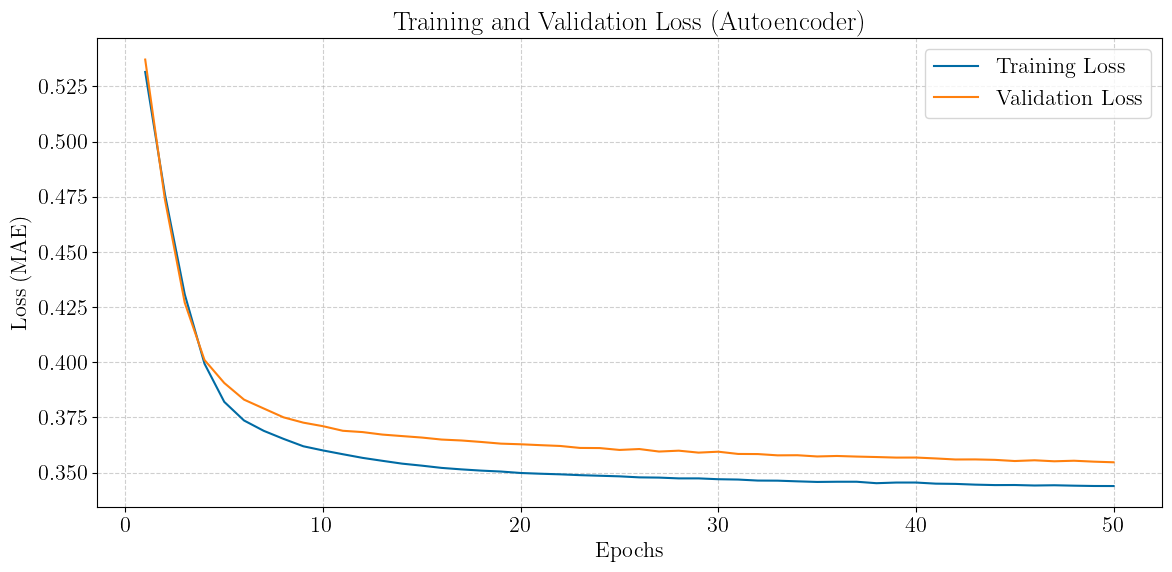

In [43]:
if training:
    fig = make_loss_plot(history)
    plt.show()

In [44]:
model = keras.models.load_model('best_model_fd004.keras')

In [45]:
Y_train_pred = model.predict(X_train)
train_mae_loss = np.mean(np.abs(Y_train_pred - Y_train), axis=(1, 2))

# Set the threshold: Anything 3 standard deviations above the mean error is a "Failure"
threshold = np.percentile(train_mae_loss, 97.5)

print(f"Quiet Failure Threshold: {threshold}")

Y_test_pred = model.predict(X_test)
test_mae_loss = np.mean(np.abs(Y_test_pred - Y_test), axis=(1, 2))

# Identify which units have crossed the threshold
is_failing = test_mae_loss > threshold

print(is_failing)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Quiet Failure Threshold: 0.43159182574403315
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
[ True False False False False False False  True False False  True  True
 False  True False False  True False  True  True False False  True False
 False  True False  True  True False False  True  True  True  True False
  True False  True False  True False  True  True  True False False  True
 False False False False False  True False  True  True False  True  True
 False  True  True  True  True  True False  True False False False False
  True False False  True False False False  True False False  True False
  True False False False False False False False  True  True  True  True
  True False  True False False False False  True  True False False  True
 False  True False  True  True False  True False  True False  True False
 False False False False False False  True  True False  True False False
 False False  True False False False False  True False  True False False
 Fa

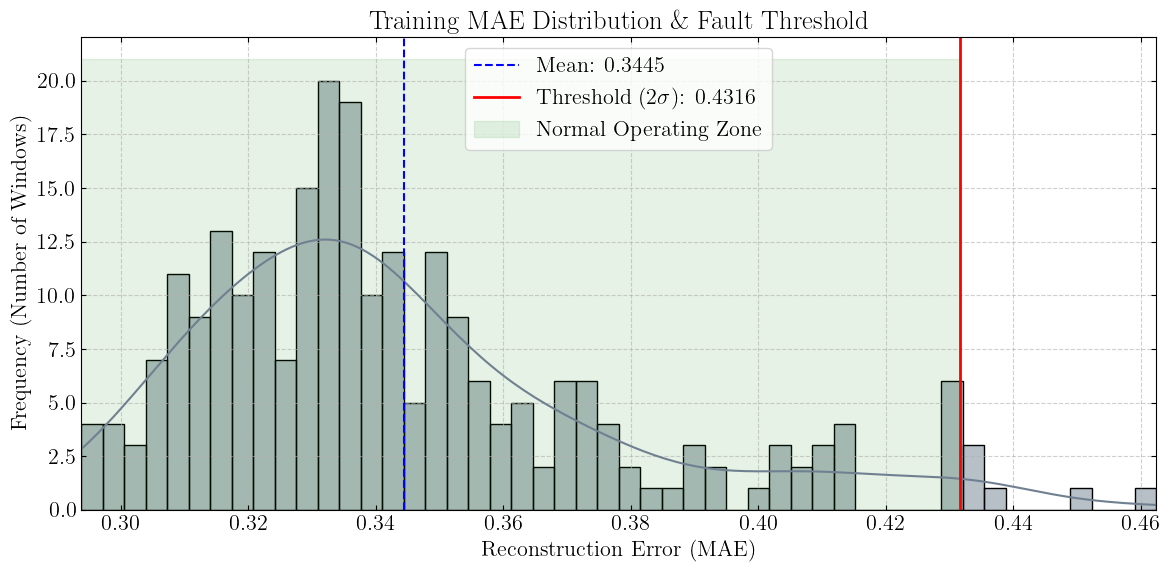

In [46]:
fig = plot_threshold_justification(train_mae_loss, threshold)
plt.show()

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
No Failure detected above threshold.


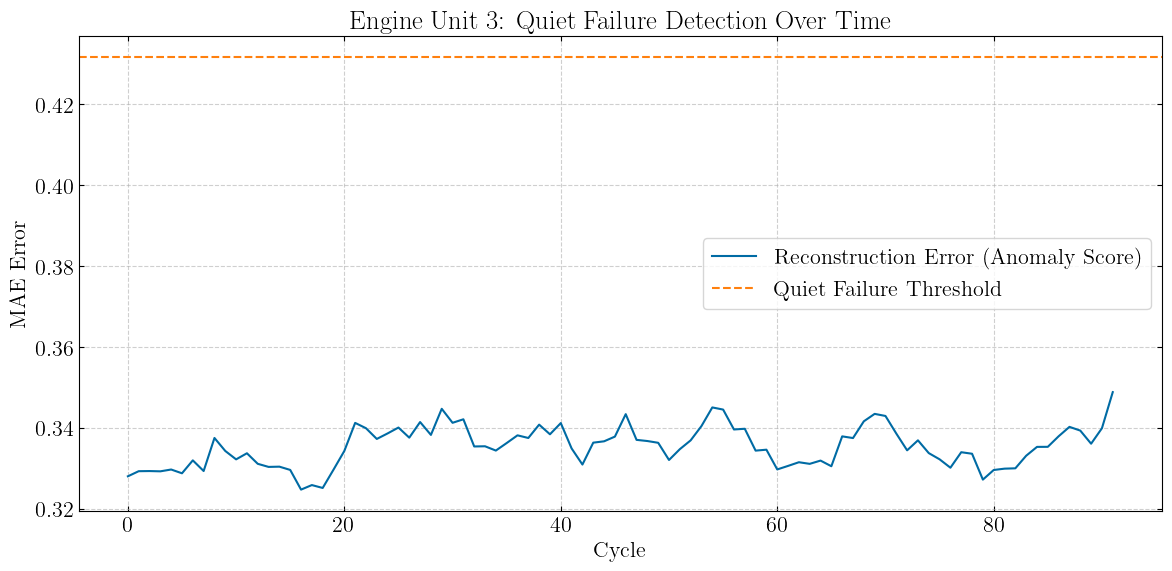

In [47]:
anomaly_score = failure_detection(df_test, model, 3, threshold, wsize, ops, relevant_sensors)

fig = failure_plot(anomaly_score, threshold, 3)
plt.show()

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Quiet Failure detected at Cycle: 152


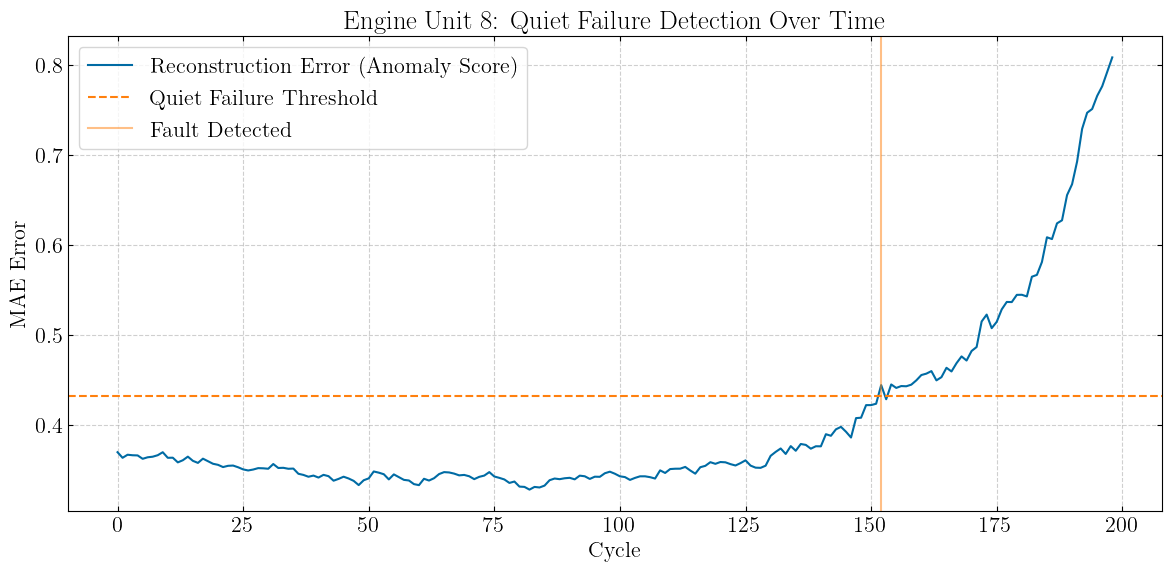

In [48]:
anomaly_score = failure_detection(df_test, model, 8, threshold, wsize, ops, relevant_sensors)

fig = failure_plot(anomaly_score, threshold, 8)
plt.show()

In [49]:
rul_truth = pd.read_csv(os.path.join(path, 'RUL_FD004.txt'), header=None).values.flatten()

audit_df = generate_audit_results(df_test, rul_truth, model, wsize, ops, relevant_sensors)

print("Top 10 Engines with Highest Anomaly Scores:")
audit_df.head(10)

Top 10 Engines with Highest Anomaly Scores:


,Unit,Max_Anomaly_Score,Actual_RUL
127,135,1.729976,7
190,206,1.647450,109
95,102,1.346878,22
166,180,1.307896,32
141,151,1.207941,31
55,61,1.191056,51
10,12,1.164406,7
165,179,1.116335,12
22,25,1.112794,39
217,235,1.076588,24


0.4544851345972109 0.01946477246637296 0.35422175899814706


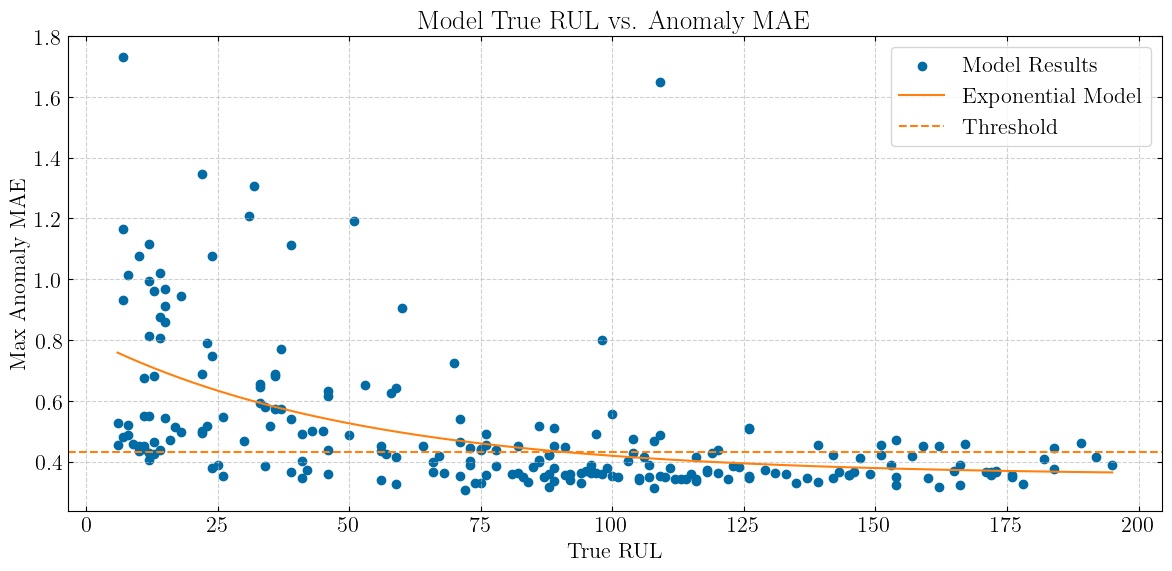

In [50]:
fig = anomaly_rul_plot(audit_df, threshold)
plt.show()

In [51]:
# 1. Using Pandas (Quickest way)
spearman_corr = audit_df['Actual_RUL'].corr(audit_df['Max_Anomaly_Score'], method='spearman')
print(f"Spearman Correlation: {spearman_corr:.4f}")

# 2. Using SciPy (Gives you a p-value for scientific proof)
rho, p_value = spearmanr(audit_df['Actual_RUL'], audit_df['Max_Anomaly_Score'])

print(f"Spearman's rho: {rho:.4f}")
print(f"P-value: {p_value:.4e}")

if p_value < 0.05:
    print("The correlation is statistically significant.")

Spearman Correlation: -0.5953
Spearman's rho: -0.5953
P-value: 3.0030e-23
The correlation is statistically significant.
